<a href="https://colab.research.google.com/github/nayomipavithra/Linear-Regression/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Simple Linear Regression


 *Task* : Predict student scores given the number of hours spend by the student for studies

*input* : Hours studies

*Output* : Score

In [2]:
import pandas as pd
import numpy as np

In [5]:
data = {'Hours': [2.5, 5.1, 3.2, 8.5, 1.5],
        'Scores': [21, 47, 27, 75, 20]}
df = pd.DataFrame(data)

In [7]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,1.5,20


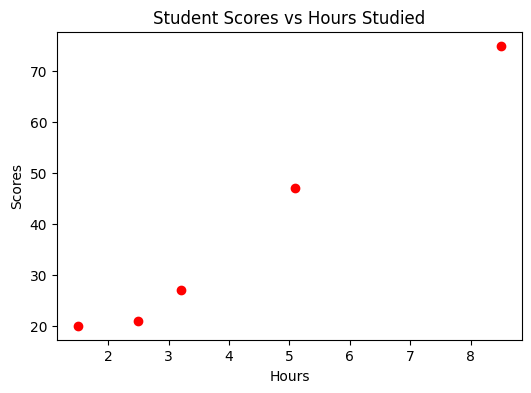

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(df['Hours'],df['Scores'],'ro')
plt.title('Student Scores vs Hours Studied')
plt.xlabel('Hours')
plt.ylabel('Scores')

plt.show()

Find Coefficients

calculate the mean of the input and output

In [10]:
xmean = np.mean(df['Hours'])
ymean = np.mean(df['Scores'])

Calculate the terms needed for the numator and denominator of beta

In [11]:
df['xycov'] = (df['Hours'] - xmean) * (df['Scores'] - ymean)
df['xvar'] = (df['Hours'] - xmean)**2

Calculate the Coefficients

In [12]:
slope = df['xycov'].sum() / df['xvar'].sum()
intercept = ymean - (slope * xmean)
print(f'slope ={slope}')
print(f'intercept = {intercept}')

slope =8.39131005513258
intercept = 3.092150170648466


Making Prediction

In [13]:
intercept + (slope * 7)

np.float64(61.83132055657653)

In [14]:
scores_predicted = intercept + (slope * df['Hours'])

Compute the score of a student who studied for 7 hours

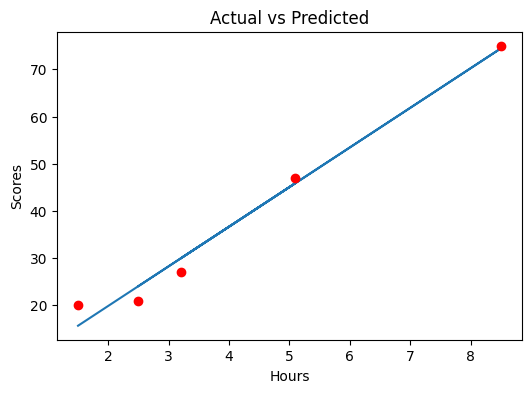

In [15]:
plt.figure  (figsize=(6,4))
plt.plot(df['Hours'],scores_predicted)
plt.plot(df['Hours'],df['Scores'],'ro')
plt.title('Actual vs Predicted')
plt.xlabel('Hours')
plt.ylabel('Scores')

plt.show()

2. Multiple Linear Regression

Task : Predict petrol consumption of a country given various factors such as tax,distance of highways and population with driving licence.

Input : Tax,distance of highways, average income and population with driving licence

Output : Expected petrol comsumption

In [17]:
import pandas as pd

data = {
    'Petrol_tax': [9.0, 9.0, 9.0, 7.5, 8.0],
    'Average_income': [3571, 4092, 3865, 4870, 4399],
    'Paved_Highways': [1976, 1250, 1586, 2351, 431],
    'Population_Driver_licence(%)': [0.525, 0.572, 0.580, 0.529, 0.544],
    'Petrol_Consumption': [541, 524, 561, 414, 410]
}

df = pd.DataFrame(data)
print(df)

   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0         9.0            3571            1976                         0.525   
1         9.0            4092            1250                         0.572   
2         9.0            3865            1586                         0.580   
3         7.5            4870            2351                         0.529   
4         8.0            4399             431                         0.544   

   Petrol_Consumption  
0                 541  
1                 524  
2                 561  
3                 414  
4                 410  


In [20]:
df.head(5)

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [22]:
df.shape

(5, 5)

In [23]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Petrol_tax,5.0,8.50,0.71,7.50,8.00,9.00,9.00,9.00
Average_income,5.0,4159.40,499.95,3571.00,3865.00,4092.00,4399.00,4870.00
Paved_Highways,5.0,1518.80,735.13,431.00,1250.00,1586.00,1976.00,2351.00
Population_Driver_licence(%),5.0,0.55,0.02,0.52,0.53,0.54,0.57,0.58
Petrol_Consumption,5.0,490.00,72.41,410.00,414.00,524.00,541.00,561.00


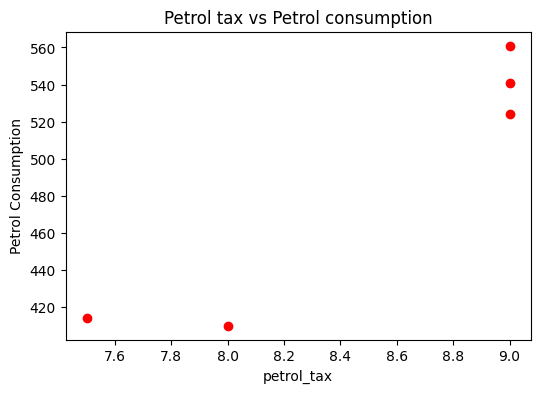

In [25]:
plt.figure  (figsize=(6,4))
plt.plot(df['Petrol_tax'],df['Petrol_Consumption'],'ro')
plt.title('Petrol tax vs Petrol consumption')
plt.xlabel('petrol_tax')
plt.ylabel('Petrol Consumption')

plt.show()

Identify Outliers

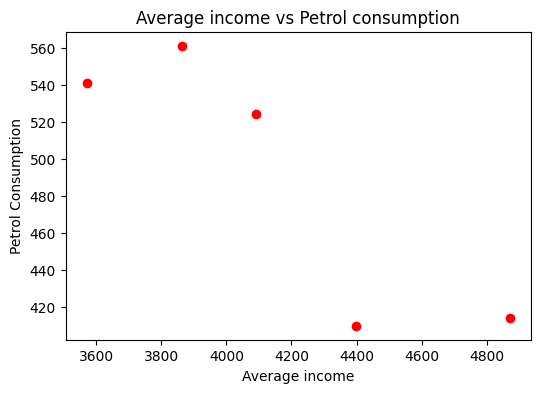

In [26]:
plt.figure  (figsize=(6,4))
plt.plot(df['Average_income'],df['Petrol_Consumption'],'ro')
plt.title('Average income vs Petrol consumption')
plt.xlabel('Average income')
plt.ylabel('Petrol Consumption')

plt.show()

Train the model

In [28]:
y = df['Petrol_Consumption']
x = df[['Average_income', 'Paved_Highways', 'Population_Driver_licence(%)', 'Petrol_tax']]

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [30]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [31]:
regressor.intercept_

np.float64(-1419.0428112550744)

In [32]:
regressor.coef_

array([9.52991932e-02, 2.40181686e-02, 2.45295081e+01, 1.73265722e+02])

Make predictions

In [33]:
y_pred = regressor.predict(x_test)

In [34]:
results = pd.DataFrame ({'Actual':y_test,'Predicted':y_pred})
print(results)

   Actual   Predicted
1     524  574.366576


Evaluating the model

In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(f'Mean Absolute Error : {mae}')
print(f'Mean Squared Error : {mse}')
print(f'Root Mean Squared Error : {rmse}')

Mean Absolute Error : 50.3665761457205
Mean Squared Error : 2536.791992642661
Root Mean Squared Error : 50.3665761457205


In [36]:
regressor.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [37]:
regressor.score(x_train,y_train)

1.0

Possible improvements:
  increase size of the data
  Try non linear relation
  May required more features